In [18]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
dtypes: float64(14), int64(2)
memory usage: 1.7 MB


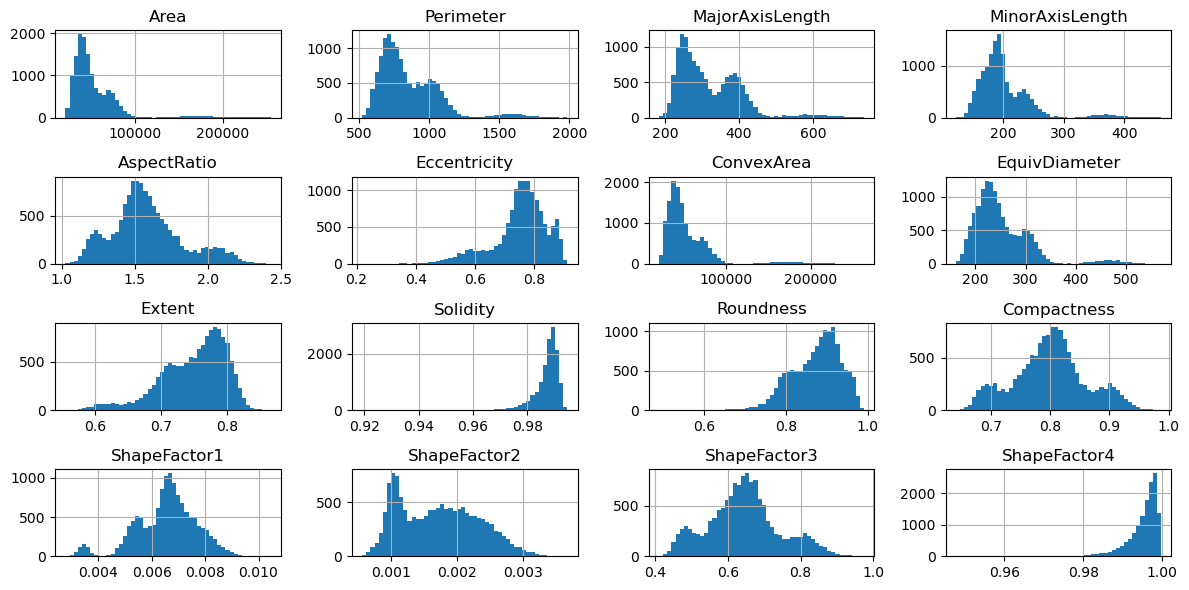

In [14]:
# fetch dataset 
dry_bean = fetch_ucirepo(id=602) 
  
# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 

X.info()
X.hist(figsize=(12,6), bins=50)
plt.tight_layout()
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [15]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64", "int64"]).columns),
])

In [21]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", BaggingClassifier())
])

param_distribution = [
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__max_depth": [3, 5, 8, 12, 20]

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": [None, 5, 10, 15, 20, 30]

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": randint(2, 6)
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distribution,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    n_iter=80
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_

/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:

KeyboardInterrupt: 

In [ ]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print()